## Shell Contact Example

In [1]:
# !pip install debugpy

In [2]:
import numpy as np

import dismech


geom = dismech.GeomParams(rod_r0=0.005,
                          shell_h=0.001)

material = dismech.Material(density=2000,
                            youngs_rod=0,
                            youngs_shell=1e9,
                            poisson_rod=0,
                            poisson_shell=0.5)

shell_contact_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=False,   # no twisting
                                  use_mid_edge=False,
                                  use_line_search=True,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=5e-4,
                                  max_iter=120,
                                  total_time=2,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2)

env = dismech.Environment()
env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))
env.add_force('floorContact', ground_z=-1e-3, stiffness=50, delta=1e-2, h=1e-3)
env.add_force('selfContact', delta=1e-4, h=1e-3, kc=10)
env.add_force('damping', eta = 0.1)
#env.set_static()   

# geo = dismech.Geometry.from_txt('2random_mesh_20.txt')
# geo = dismech.Geometry.from_txt('2random_mesh_8.txt')
# geo = dismech.Geometry.from_txt('input_shell_for_self_contact.txt')
geo = dismech.Geometry.from_txt('input_shell_more_curved_rand20_scaled.txt')

robot = dismech.SoftRobot(geom, material, geo, shell_contact_sim, env)


fixed_points = np.array(np.where(
    (robot.state.q[:robot.end_node_dof_index].reshape(-1, 3)[:, 2] < 0.001) # (robot.state.q[:robot.end_node_dof_index].reshape(-1, 3)[:, 2] < 0.001)
)[0])




robot = robot.fix_nodes(fixed_points)

# u = robot.state.u
# u[11] = -0.5
# u[14] = -0.5
# u[17] = -0.5

### Time Stepping

As we are performing a static simulation, we must change gravity for each time step.

In [3]:
stepper = dismech.ImplicitEulerTimeStepper(robot)

robots = stepper.simulate()

qs = np.stack([robot.state.q for robot in robots])

delta: 0.1
h: 1.0
K1: 150.0
scale:  1000.0
kc:  10
upper limit for quadratic: 1.9
upper limit for smooth: 2.1
iter: 1, error: 0.297
current_time:  0.0005
iter: 1, error: 0.581
iter: 2, error: 0.000
current_time:  0.001
iter: 1, error: 0.858
iter: 2, error: 0.001
current_time:  0.0015
iter: 1, error: 1.129
iter: 2, error: 0.002
current_time:  0.002
iter: 1, error: 1.392
iter: 2, error: 0.002
current_time:  0.0025
iter: 1, error: 1.650
iter: 2, error: 0.003
current_time:  0.003
iter: 1, error: 1.903
iter: 2, error: 0.005
current_time:  0.0035
iter: 1, error: 2.150
iter: 2, error: 0.006
current_time:  0.004
iter: 1, error: 2.394
iter: 2, error: 0.007
current_time:  0.0045000000000000005
iter: 1, error: 2.632
iter: 2, error: 0.008
current_time:  0.005
iter: 1, error: 2.867
iter: 2, error: 0.010
current_time:  0.0055
iter: 1, error: 3.097
iter: 2, error: 0.011
current_time:  0.006
iter: 1, error: 3.323
iter: 2, error: 0.014
current_time:  0.006500000000000001
iter: 1, error: 3.545
iter: 2, 

In [4]:
t = np.arange(robot.sim_params.total_time, step=robot.sim_params.dt)
options = dismech.AnimationOptions(title='Shell contact p2p', plot_step=100)

fig = dismech.get_interactive_animation_plotly(robot, t, qs, options)
fig.show()

41


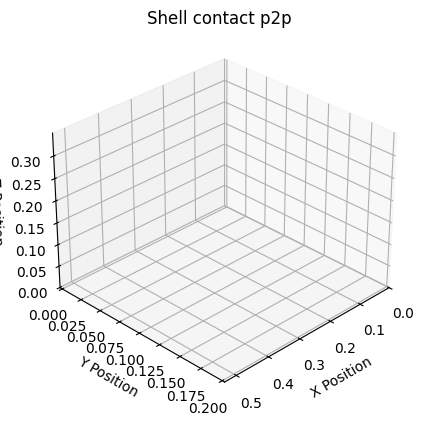

In [5]:
ani = dismech.get_animation(robot, t, qs, options)
ani.save('selfcontact_final.gif')

In [6]:
import numpy as np

def logDataForRendering(dofs, time_array, softRobot, Nsteps, static_sim, mapNodetoDOF):
    dof_with_time = np.hstack([time_array, dofs])
    print(np.shape(dof_with_time), np.shape(time_array), np.shape(dofs))
    n_rod_nodes = len(np.unique(softRobot.rod_edges))
    n_faces = len(softRobot.face_nodes_shell)
    print(np.shape(softRobot.face_nodes_shell))
    print(n_faces)

    if static_sim:
        rod_data = np.zeros((n_rod_nodes, 4))
        for j in range(n_rod_nodes):
            rod_data[j, 0] = dof_with_time[0, -1]
            rod_data[j, 1:] = dof_with_time[-1, 1 + mapNodetoDOF(j)]

        shell_data = np.zeros((3 * n_faces, 3))
        for j in range(n_faces):
            n1 = softRobot.face_nodes_shell[j, 0]
            n2 = softRobot.face_nodes_shell[j, 1]
            n3 = softRobot.face_nodes_shell[j, 2]
            shell_data[3*j:3*j+3, :] = np.vstack([
                dof_with_time[-1, 1 + mapNodetoDOF(n1)],
                dof_with_time[-1, 1 + mapNodetoDOF(n2)],
                dof_with_time[-1, 1 + mapNodetoDOF(n3)]
            ])

        np.savetxt('rawDataRod.txt', rod_data, fmt='%.6e')
        np.savetxt('rawDataShell.txt', shell_data, fmt='%.6e')
        return rod_data, shell_data

    # For dynamic case
    rod_data = np.zeros((n_rod_nodes * Nsteps, 4))
    for i in range(Nsteps-1):
        for j in range(n_rod_nodes):
            rod_data[i * n_rod_nodes + j, 0] = dof_with_time[i, 0]
            rod_data[i * n_rod_nodes + j, 1:] = dof_with_time[i, 1 + mapNodetoDOF(j)]

    shell_data = np.zeros((3 * n_faces * Nsteps, 3))
    for i in range(Nsteps-1):
        for j in range(n_faces):
            n1 = softRobot.face_nodes_shell[j, 0]
            n2 = softRobot.face_nodes_shell[j, 1]
            n3 = softRobot.face_nodes_shell[j, 2]
            idx = i * 3 * n_faces + 3 * j
            shell_data[idx:idx+3, :] = np.vstack([
                dof_with_time[i, 1 + mapNodetoDOF(n1)],
                dof_with_time[i, 1 + mapNodetoDOF(n2)],
                dof_with_time[i, 1 + mapNodetoDOF(n3)]
            ])

    np.savetxt('rawDataRod.txt', rod_data, fmt='%.6e')
    np.savetxt('rawDataShell.txt', shell_data, fmt='%.6e')

    return rod_data, shell_data


In [7]:
# from dismech.logging import logDataForRendering
print(np.shape(t.reshape(-1, 1)), np.shape(qs))
rod_data, shell_data = logDataForRendering(qs, t.reshape(-1, 1), robot, len(t), robot.sim_params.static_sim, robot.map_node_to_dof)


(4000, 1) (4000, 327)
(4000, 328) (4000, 1) (4000, 327)
(168, 3)
168


In [8]:
import numpy as np

# Constants
rod_radius = 0.1
scaleFactor = 100

# === Load and write rod data ===
df = np.loadtxt('rawDataRod.txt')
n_rod_nodes = len(np.unique(robot.rod_edges))  # Assuming softRobot is defined
n_Tri = len(robot.face_nodes_shell)      # Used later for shell

with open('rodData.js', 'w') as fileID:
    fileID.write(f'nNodes = {n_rod_nodes};\n')
    fileID.write(f'rodRadius = {rod_radius};\n')
    fileID.write('nodesRod = [\n')

    for row in df:
        t, x, y, z = row
        x, y, z = x * scaleFactor, y * scaleFactor, z * scaleFactor
        fileID.write(f'{t}, 1, {x}, {y}, {z},\n')

    fileID.write(']\n;\n')

# === Load and write shell data ===
ds = np.loadtxt('rawDataShell.txt')

with open('shellData.js', 'w') as shell_fileID:
    shell_fileID.write(f'nTri = {n_Tri},\n')
    shell_fileID.write('nodes = [\n')

    for row in ds:
        x, y, z = row * scaleFactor
        shell_fileID.write(f'{x}, {y}, {z},\n')

    shell_fileID.write('];\n')


/var/folders/z0/3frv2l990hb5ryd49z8vm4w80000gn/T/ipykernel_4473/835871820.py:8: UserWarning:

loadtxt: input contained no data: "rawDataRod.txt"

